In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import os 


In [5]:
os.listdir(r'/sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run0046.h5')

['xcs101628926_Run0007.h5',
 'xcs101628926_Run0031.h5',
 'xcs101628926_Run0003.h5',
 'xcs101628926_Run0025.h5',
 'xcs101628926_Run0034.h5',
 'xcs101628926_Run0036.h5',
 'xcs101628926_Run0009.h5',
 'xcs101628926_Run0045.h5',
 'xcs101628926_Run0008.h5',
 'xcs101628926_Run0011.h5',
 'xcs101628926_Run0006.h5',
 'xcs101628926_Run0018.h5',
 'xcs101628926_Run0012.h5',
 'xcs101628926_Run0041.h5',
 'xcs101628926_Run0028.h5',
 'xcs101628926_Run0020.h5',
 'xcs101628926_Run0017.h5',
 'xcs101628926_Run0023.h5',
 'xcs101628926_Run0026.h5',
 'xcs101628926_Run0016.h5',
 'xcs101628926_Run0033.h5',
 'xcs101628926_Run0021.h5',
 'xcs101628926_Run0002.h5',
 'xcs101628926_Run0030.h5',
 'xcs101628926_Run0029.h5',
 'xcs101628926_Run0040.h5',
 'xcs101628926_Run0022.h5',
 'cube',
 'xcs101628926_Run0005.h5',
 'xcs101628926_Run0042.h5',
 'xcs101628926_Run0035.h5',
 'xcs101628926_Run0027.h5',
 'xcs101628926_Run0010.h5',
 'xcs101628926_Run0044.h5',
 'xcs101628926_Run0001.h5',
 'xcs101628926_Run0015.h5',
 'xcs101628

In [114]:
file=r'/sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run0046.h5'
#file=r'/sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run0045.h5'

In [115]:
fh=h5.File(file)

In [116]:
fh.keys()

<KeysViewHDF5 ['Sums', 'UserDataCfg', 'ai', 'damage', 'diodeGon', 'ebeam', 'enc', 'epics', 'epicsOnce', 'epicsUser', 'epix10k2M', 'epix10k2M_env', 'epix_2', 'epix_2_env', 'event_time', 'evr', 'feeBld', 'fiducials', 'gas_detector', 'ipm2', 'ipm4', 'ipm5', 'lightStatus', 'phase_cav', 'scan', 'tt']>

In [117]:
fh['epix_2'].keys()

<KeysViewHDF5 ['ROI_com', 'ROI_max', 'ROI_mean', 'ROI_sum']>

In [118]:
epix=fh['epix_2/ROI_sum']
ipm=fh['ipm5/sum']
dccm_sets=fh['epicsUser/dccm_E_setpoint']
dccm=fh['epicsUser/dccm_E']

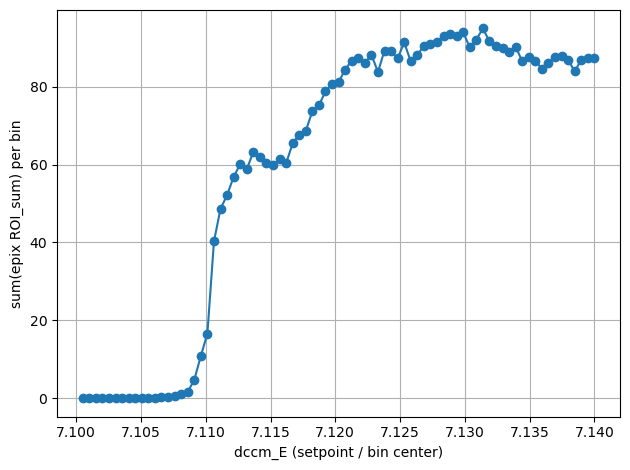

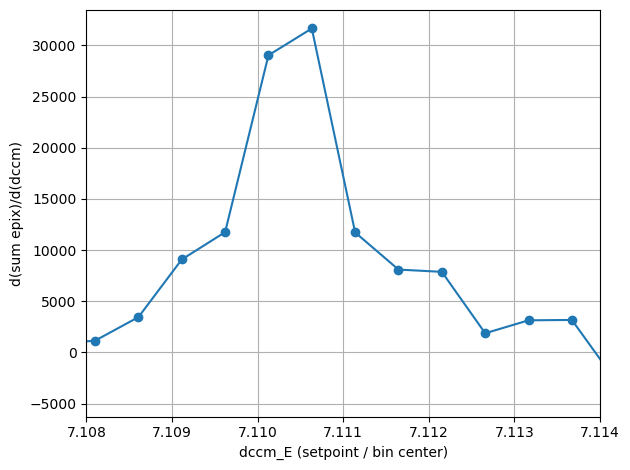

In [124]:
import numpy as np

sl = slice(500, -500)

epix = fh['epix_2/ROI_sum'][sl]
ipm  = fh['ipm5/sum'][sl]
dccm = fh['epicsUser/dccm_E'][sl]
dccm_sets = np.unique(fh['epicsUser/dccm_E_setpoint'][sl])  # usually not per-event

# Define bin edges halfway between setpoints (plus outer edges)
sets = np.asarray(dccm_sets)
order = np.argsort(sets)
sets_sorted = sets[order]

mid = (sets_sorted[:-1] + sets_sorted[1:]) / 2.0
edges = np.r_[sets_sorted[0] - (mid[0] - sets_sorted[0]),
              mid,
              sets_sorted[-1] + (sets_sorted[-1] - mid[-1])]

# Bin index per event (0..nbins-1), out-of-range -> ignored
idx = np.digitize(dccm, edges) - 1
nb = len(sets_sorted)
valid = (idx >= 0) & (idx < nb)

# Sums per bin
epix_sum = np.bincount(idx[valid], weights=epix[valid], minlength=nb)
ipm_sum  = np.bincount(idx[valid], weights=ipm[valid],  minlength=nb)
counts   = np.bincount(idx[valid], minlength=nb)


order = np.argsort(dccm)
dccm_s = dccm[order]
epix_s = epix[order]
ipm_s  = ipm[order]
# epix_sum and ipm_sum correspond to bins centered on dccm_sets
plt.plot(sets_sorted, epix_sum/ipm_sum, marker='o')
plt.xlabel('dccm_E (setpoint / bin center)')
plt.ylabel('sum(epix ROI_sum) per bin')
plt.title
plt.grid(True)
plt.tight_layout()
# x = dccm bin centers, y = summed signal
x = sets_sorted          # or dccm_sets if that matches your epix_sum ordering
y = epix_sum/ipm_sum

# numerical derivative dy/dx
dy_dx = np.gradient(y, x)

plt.figure()
plt.plot(x, dy_dx, marker='o')
plt.xlabel('dccm_E (setpoint / bin center)')
plt.ylabel('d(sum epix)/d(dccm)')
plt.xlim(7.108,7.114)
plt.grid(True)
plt.tight_layout()

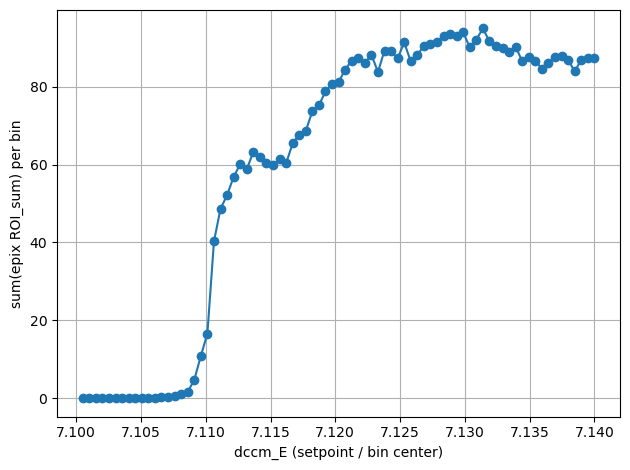

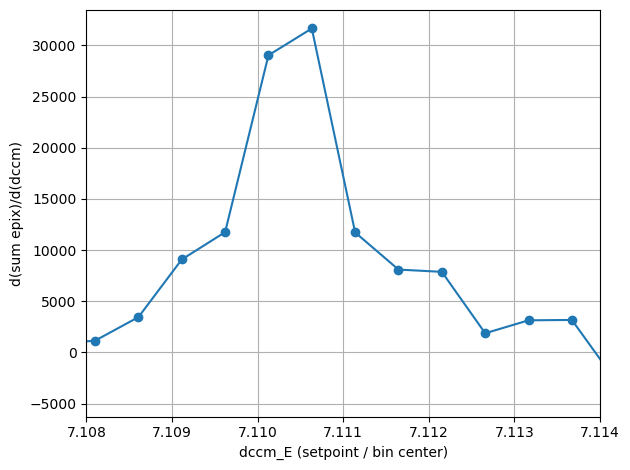

In [107]:
import numpy as np
import matplotlib.pyplot as plt

lo, hi = 7.108, 7.114
x_ref = 7.1112

m = (x >= lo) & (x <= hi) & np.isfinite(dy_dx)
xw = x[m]
dw = dy_dx[m]

j = np.argmax(dw)
x_max = xw[j]
d_max = dw[j]

# (optional) sub-grid refine with quadratic fit around the max
x_peak, d_peak = x_max, d_max
if 0 < j < len(xw)-1:
    a, b, c = np.polyfit(xw[j-1:j+2], dw[j-1:j+2], 2)
    if a != 0:
        x_peak = -b/(2*a)
        d_peak = a*x_peak**2 + b*x_peak + c

dx = x_peak - x_ref

plt.figure()
plt.plot(x, dy_dx, marker='o')
plt.xlim(lo, hi)
plt.xlabel('dccm_E (keV)')
plt.ylabel('d(epix_sum/ipm_sum)/d(dccm)')
plt.grid(True)

# vertical lines
plt.axvline(x_peak, color='r', ls='--', lw=2, label=f"max @ {x_peak:.6f} keV")
plt.axvline(x_ref,  color='k', ls=':',  lw=2, label=f"Fe foil @ {x_ref:.4f} keV")

# annotate difference
yl = plt.ylim()
y_text = yl[0] + 0.85*(yl[1]-yl[0])
plt.text(min(x_peak, x_ref) + 0.00005, y_text,
         f"ΔE = {dx:+.6f} keV ({dx*1e3:+.2f} eV)",
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.legend()
plt.tight_layout()

print(f"Max derivative at {x_peak:.6f} keV")
print(f"Reference      at {x_ref:.4f} keV")
print(f"ΔE = {dx:+.6f} keV  ({dx*1e3:+.2f} eV)")

ValueError: attempt to get argmax of an empty sequence

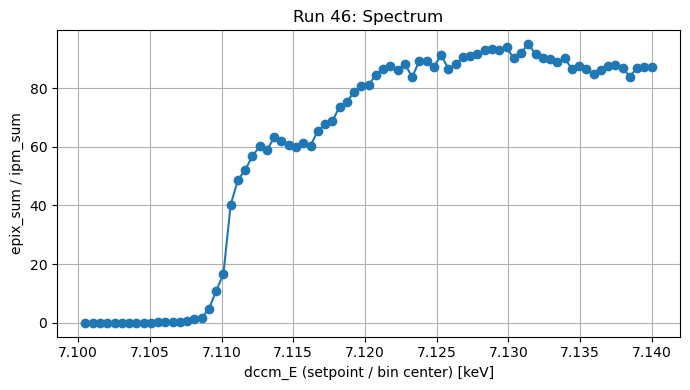

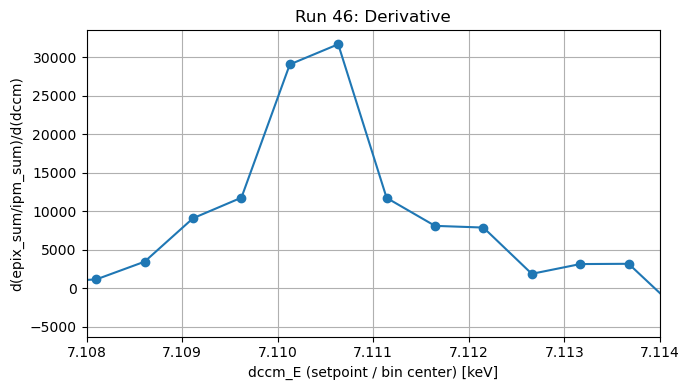

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

run = 46
file = f"/sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run{run:04d}.h5"

lo, hi = 7.108, 7.114
x_ref = 7.1112
sl = slice(500, -500)

with h5py.File(file, "r") as fh:
    epix = fh['epix_2/ROI_sum'][sl]
    ipm  = fh['ipm5/sum'][sl]
    dccm = fh['epicsUser/dccm_E'][sl]
    dccm_sets = fh['epicsUser/dccm_E_setpoint'][:]

# bin by setpoints
sets = np.asarray(dccm_sets)
order = np.argsort(sets)
sets_sorted = sets[order]

mid = (sets_sorted[:-1] + sets_sorted[1:]) / 2.0
edges = np.r_[sets_sorted[0] - (mid[0] - sets_sorted[0]),
              mid,
              sets_sorted[-1] + (sets_sorted[-1] - mid[-1])]

idx = np.digitize(dccm, edges) - 1
nb = len(sets_sorted)
valid = (idx >= 0) & (idx < nb) & np.isfinite(epix) & np.isfinite(ipm)

epix_sum = np.bincount(idx[valid], weights=epix[valid], minlength=nb)
ipm_sum  = np.bincount(idx[valid], weights=ipm[valid],  minlength=nb)

# spectrum and derivative
x = sets_sorted
y = np.full(nb, np.nan, dtype=float)
good = ipm_sum != 0
y[good] = epix_sum[good] / ipm_sum[good]
dy_dx = np.gradient(y, x)

# max derivative in window (no interpolation)
m = (x >= lo) & (x <= hi) & np.isfinite(dy_dx)
xw, dw = x[m], dy_dx[m]
j = np.argmax(dw)
x_max, d_max = xw[j], dw[j]
dE = x_max - x_ref

# plots
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7, 6))
fig.suptitle(f"Run {run}: epix_sum/ipm_sum and derivative vs DCCM energy")

ax0.plot(x, y, marker='o')
ax0.set_xlabel('dccm_E (keV)')
ax0.set_ylabel('epix_sum / ipm_sum')
ax0.grid(True)
ax0.axvline(x_max, color='r', ls='--', lw=2)
ax0.axvline(x_ref, color='k', ls=':', lw=2)

ax1.plot(x, dy_dx, marker='o')
ax1.set_xlim(lo, hi)
ax1.set_xlabel('dccm_E (keV)')
ax1.set_ylabel('d(epix_sum/ipm_sum)/d(dccm)')
ax1.grid(True)
ax1.axvline(x_max, color='r', ls='--', lw=2, label=f"max @ {x_max:.6f} keV")
ax1.axvline(x_ref, color='k', ls=':', lw=2, label=f"Fe foil @ {x_ref:.4f} keV")

yl = ax1.get_ylim()
y_text = yl[0] + 0.85*(yl[1]-yl[0])
ax1.text(min(x_max, x_ref) + 0.00005, y_text,
         f"ΔE = {dE:+.6f} keV ({dE*1e3:+.2f} eV)",
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend()
fig.tight_layout(rect=[0, 0, 1, 0.96])

print(f"File: {file}")
print(f"Max derivative (grid) at {x_max:.6f} keV, value {d_max:.6g}")
print(f"Reference at {x_ref:.4f} keV")
print(f"ΔE = {dE:+.6f} keV ({dE*1e3:+.2f} eV)")

Run 52 file: /sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run0052.h5
Max derivative (grid) at 7.112658 keV, value 0.943779
Reference at 7.1112 keV
ΔE = +0.001458 keV (+1.46 eV)


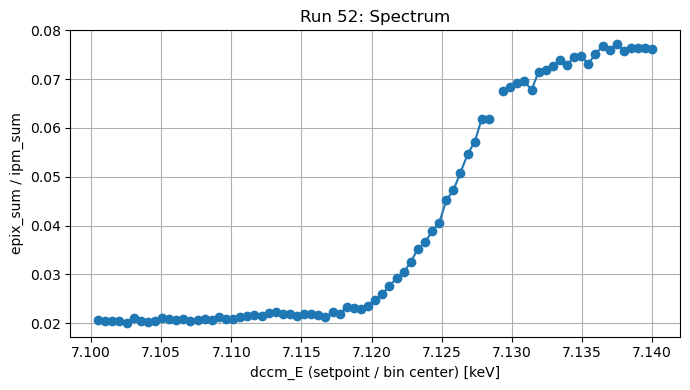

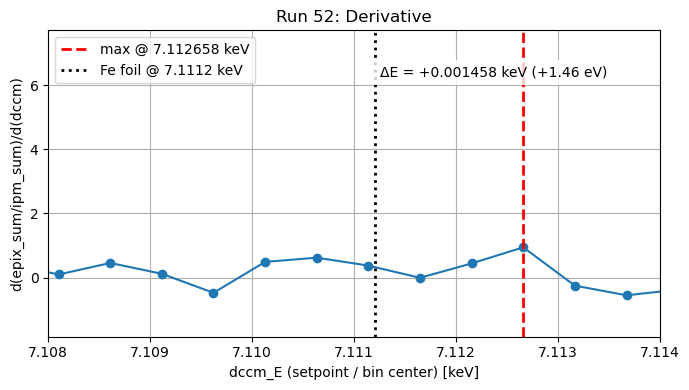

In [128]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

run = 52
file = f"/sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run{run:04d}.h5"

sl = slice(500, -500)
lo, hi = 7.108, 7.114
x_ref = 7.1112

with h5py.File(file, "r") as fh:
    epix = fh['epix_2/ROI_sum'][sl]
    ipm  = fh['ipm5/sum'][sl]
    dccm = fh['epicsUser/dccm_E'][sl]
    dccm_sets = np.unique(fh['epicsUser/dccm_E_setpoint'][sl])

# bin edges from setpoints
x = np.sort(np.asarray(dccm_sets))
mid = (x[:-1] + x[1:]) / 2.0
edges = np.r_[x[0] - (mid[0] - x[0]), mid, x[-1] + (x[-1] - mid[-1])]

# assign each event to a bin
idx = np.digitize(dccm, edges) - 1
nb = len(x)
valid = (idx >= 0) & (idx < nb) & np.isfinite(epix) & np.isfinite(ipm)

# sums per bin
epix_sum = np.bincount(idx[valid], weights=epix[valid], minlength=nb)
ipm_sum  = np.bincount(idx[valid], weights=ipm[valid],  minlength=nb)

# ratio (avoid divide-by-0)
y = np.full(nb, np.nan, dtype=float)
ok = ipm_sum != 0
y[ok] = epix_sum[ok] / ipm_sum[ok]

# derivative only where y is finite
dy_dx = np.full(nb, np.nan, dtype=float)
mask = np.isfinite(y)
dy_dx[mask] = np.gradient(y[mask], x[mask])

# find max derivative in window (no interpolation)
mw = (x >= lo) & (x <= hi) & np.isfinite(dy_dx)
xw, dw = x[mw], dy_dx[mw]
j = np.argmax(dw)
x_max, d_max = xw[j], dw[j]
dE = x_max - x_ref

# ---- plots (two figures) ----
plt.figure(figsize=(7, 4))
plt.plot(x, y, marker='o')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('epix_sum / ipm_sum')
plt.title(f'Run {run}: Spectrum')
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(7, 4))
plt.plot(x, dy_dx, marker='o')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('d(epix_sum/ipm_sum)/d(dccm)')
plt.title(f'Run {run}: Derivative')
plt.xlim(lo, hi)
plt.grid(True)

# vertical lines + annotation
plt.axvline(x_max, color='r', ls='--', lw=2, label=f"max @ {x_max:.6f} keV")
plt.axvline(x_ref, color='k', ls=':', lw=2, label=f"Fe foil @ {x_ref:.4f} keV")

yl = plt.ylim()
y_text = yl[0] + 0.85*(yl[1] - yl[0])
plt.text(min(x_max, x_ref) + 0.00005, y_text,
         f"ΔE = {dE:+.6f} keV ({dE*1e3:+.2f} eV)",
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.legend()
plt.tight_layout()

print(f"Run {run} file: {file}")
print(f"Max derivative (grid) at {x_max:.6f} keV, value {d_max:.6g}")
print(f"Reference at {x_ref:.4f} keV")
print(f"ΔE = {dE:+.6f} keV ({dE*1e3:+.2f} eV)")

Run 52 file: /sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run0052.h5
Max derivative (grid) at 7.112658 keV, value 0.943779
Reference at 7.1112 keV
ΔE = +0.001458 keV (+1.46 eV)


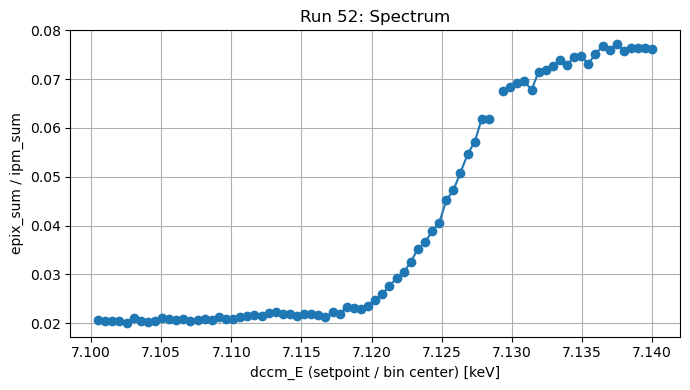

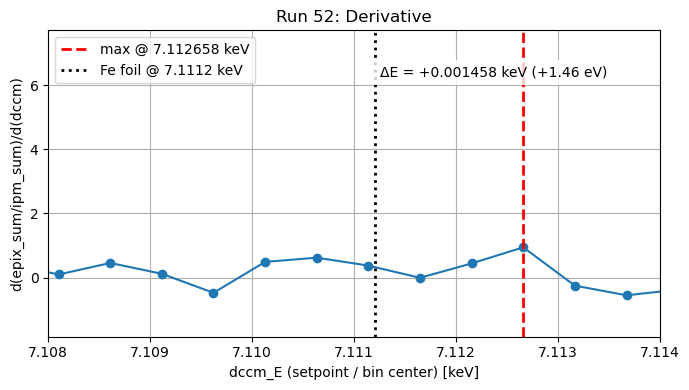

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

run = 52
file = f"/sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run{run:04d}.h5"

sl = slice(500, -500)
lo, hi = 7.108, 7.114
x_ref = 7.1112

with h5py.File(file, "r") as fh:
    epix = fh['epix_2/ROI_sum'][sl]
    ipm  = fh['ipm5/sum'][sl]
    dccm = fh['epicsUser/dccm_E'][sl]
    dccm_sets = np.unique(fh['epicsUser/dccm_E_setpoint'][sl])

# bin edges from setpoints
x = np.sort(np.asarray(dccm_sets))
mid = (x[:-1] + x[1:]) / 2.0
edges = np.r_[x[0] - (mid[0] - x[0]), mid, x[-1] + (x[-1] - mid[-1])]

# assign each event to a bin
idx = np.digitize(dccm, edges) - 1
nb = len(x)
valid = (idx >= 0) & (idx < nb) & np.isfinite(epix) & np.isfinite(ipm)

# sums per bin
epix_sum = np.bincount(idx[valid], weights=epix[valid], minlength=nb)
ipm_sum  = np.bincount(idx[valid], weights=ipm[valid],  minlength=nb)

# ratio (avoid divide-by-0)
y = np.full(nb, np.nan, dtype=float)
ok = ipm_sum != 0
y[ok] = epix_sum[ok] / ipm_sum[ok]

# derivative only where y is finite
dy_dx = np.full(nb, np.nan, dtype=float)
mask = np.isfinite(y)
dy_dx[mask] = np.gradient(y[mask], x[mask])

# find max derivative in window (no interpolation)
mw = (x >= lo) & (x <= hi) & np.isfinite(dy_dx)
xw, dw = x[mw], dy_dx[mw]
j = np.argmax(dw)
x_max, d_max = xw[j], dw[j]
dE = x_max - x_ref

# ---- plots (two figures) ----
plt.figure(figsize=(7, 4))
plt.plot(x, y, marker='o')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('epix_sum / ipm_sum')
plt.title(f'Run {run}: Spectrum')
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(7, 4))
plt.plot(x, dy_dx, marker='o')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('d(epix_sum/ipm_sum)/d(dccm)')
plt.title(f'Run {run}: Derivative')
plt.xlim(lo, hi)
plt.grid(True)

# vertical lines + annotation
plt.axvline(x_max, color='r', ls='--', lw=2, label=f"max @ {x_max:.6f} keV")
plt.axvline(x_ref, color='k', ls=':', lw=2, label=f"Fe foil @ {x_ref:.4f} keV")

yl = plt.ylim()
y_text = yl[0] + 0.85*(yl[1] - yl[0])
plt.text(min(x_max, x_ref) + 0.00005, y_text,
         f"ΔE = {dE:+.6f} keV ({dE*1e3:+.2f} eV)",
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.legend()
plt.tight_layout()

print(f"Run {run} file: {file}")
print(f"Max derivative (grid) at {x_max:.6f} keV, value {d_max:.6g}")
print(f"Reference at {x_ref:.4f} keV")
print(f"ΔE = {dE:+.6f} keV ({dE*1e3:+.2f} eV)")

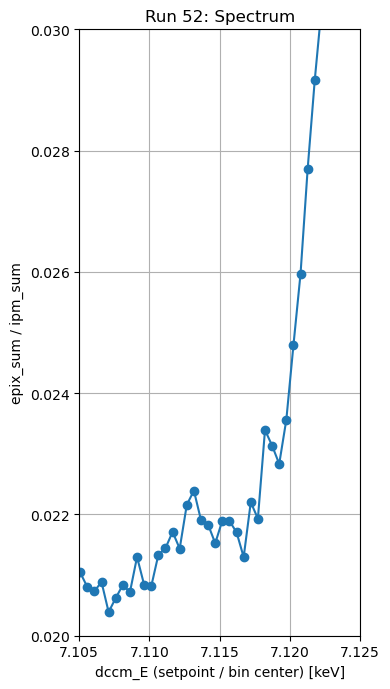

In [171]:
plt.figure(figsize=(4, 7))
plt.plot(x, y, marker='o')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('epix_sum / ipm_sum')
plt.title(f'Run {run}: Spectrum')
plt.grid(True)
plt.xlim(7.105,7.125)
plt.ylim(0.02,0.03)
plt.tight_layout()

In [165]:
import numpy as np

E = np.unique(np.concatenate([
    np.arange(7.105, 7.1081, 0.001),
    np.arange(7.109, 7.1201, 0.00025),
    np.arange(7.12025, 7.1291, 0.0005),
    np.arange(7.130, 7.1401, 0.001),
]))
E

array([7.105  , 7.106  , 7.107  , 7.108  , 7.109  , 7.10925, 7.1095 ,
       7.10975, 7.11   , 7.11025, 7.1105 , 7.11075, 7.111  , 7.11125,
       7.1115 , 7.11175, 7.112  , 7.11225, 7.1125 , 7.11275, 7.113  ,
       7.11325, 7.1135 , 7.11375, 7.114  , 7.11425, 7.1145 , 7.11475,
       7.115  , 7.11525, 7.1155 , 7.11575, 7.116  , 7.11625, 7.1165 ,
       7.11675, 7.117  , 7.11725, 7.1175 , 7.11775, 7.118  , 7.11825,
       7.1185 , 7.11875, 7.119  , 7.11925, 7.1195 , 7.11975, 7.12   ,
       7.12025, 7.12075, 7.12125, 7.12175, 7.12225, 7.12275, 7.12325,
       7.12375, 7.12425, 7.12475, 7.12525, 7.12575, 7.12625, 7.12675,
       7.12725, 7.12775, 7.12825, 7.12875, 7.13   , 7.131  , 7.132  ,
       7.133  , 7.134  , 7.135  , 7.136  , 7.137  , 7.138  , 7.139  ,
       7.14   ])

In [163]:
len(E)

78

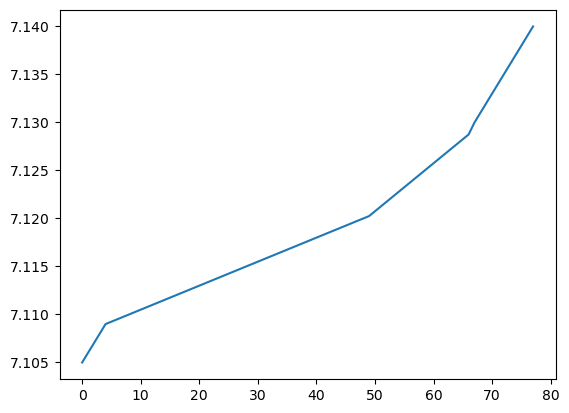

In [164]:
plt.plot(E)

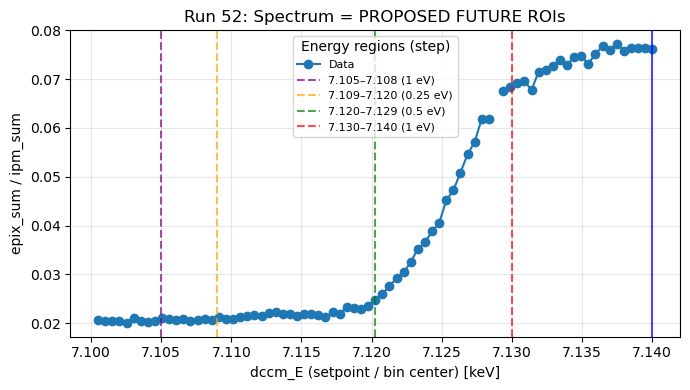

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# Define the energy regions with their step sizes (in keV)
regions = [
    (np.arange(7.105, 7.1081, 0.001), 0.001),
    (np.arange(7.109, 7.1201, 0.00025), 0.00025),
    (np.arange(7.12025, 7.1291, 0.0005), 0.0005),
    (np.arange(7.130, 7.1401, 0.001), 0.001),
]

E = np.unique(np.concatenate([reg[0] for reg in regions]))

# Extract boundaries
boundaries = []
for reg, _ in regions:
    boundaries.append(reg[0])   # start
boundaries.append(regions[-1][0][-1])  # end of last region

plt.figure(figsize=(7, 4))
plt.plot(x, y, marker='o', label='Data')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('epix_sum / ipm_sum')
plt.title(f'Run {run}: Spectrum = PROPOSED FUTURE ROIs')
plt.grid(True, alpha=0.3)

# Plot region boundaries
colors = ['purple', 'orange', 'green', 'red', 'blue']
ranges = ['7.105–7.108', '7.109–7.120', '7.120–7.129', '7.130–7.140']

for i, b in enumerate(boundaries):
    ls = '--' if i < len(boundaries)-1 else '-'
    if i < len(regions):
        step_eV = regions[i][1] * 1000  # keV to eV
        lbl = f'{ranges[i]} ({step_eV:.2g} eV)'
    else:
        lbl = None
    plt.axvline(b, color=colors[i], ls=ls, lw=1.5, alpha=0.7, label=lbl)

plt.legend(loc='best', fontsize=8, title='Energy regions (step)')
plt.tight_layout()

Run 64 file: /sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run0064.h5
Max derivative (grid) at 7.110633 keV, value 4.855
Reference at 7.1112 keV
ΔE = -0.000567 keV (-0.57 eV)


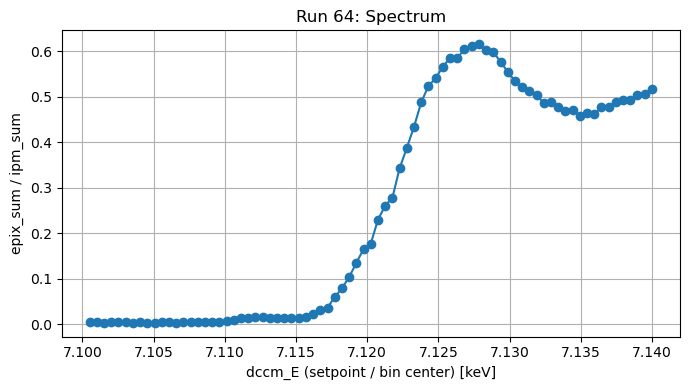

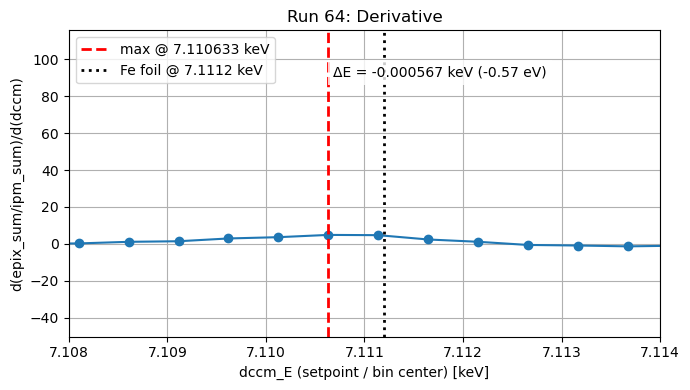

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

run = 64
file = f"/sdf/data/lcls/ds/xcs/xcs101628926/hdf5/smalldata/xcs101628926_Run{run:04d}.h5"

sl = slice(500, -500)
lo, hi = 7.108, 7.114
x_ref = 7.1112

with h5py.File(file, "r") as fh:
    epix = fh['epix_2/ROI_sum'][sl]
    ipm  = fh['ipm5/sum'][sl]
    dccm = fh['epicsUser/dccm_E'][sl]
    dccm_sets = np.unique(fh['epicsUser/dccm_E_setpoint'][sl])

# bin edges from setpoints
x = np.sort(np.asarray(dccm_sets))
mid = (x[:-1] + x[1:]) / 2.0
edges = np.r_[x[0] - (mid[0] - x[0]), mid, x[-1] + (x[-1] - mid[-1])]

# assign each event to a bin
idx = np.digitize(dccm, edges) - 1
nb = len(x)
valid = (idx >= 0) & (idx < nb) & np.isfinite(epix) & np.isfinite(ipm)

# sums per bin
epix_sum = np.bincount(idx[valid], weights=epix[valid], minlength=nb)
ipm_sum  = np.bincount(idx[valid], weights=ipm[valid],  minlength=nb)

# ratio (avoid divide-by-0)
y = np.full(nb, np.nan, dtype=float)
ok = ipm_sum != 0
y[ok] = epix_sum[ok] / ipm_sum[ok]

# derivative only where y is finite
dy_dx = np.full(nb, np.nan, dtype=float)
mask = np.isfinite(y)
dy_dx[mask] = np.gradient(y[mask], x[mask])

# find max derivative in window (no interpolation)
mw = (x >= lo) & (x <= hi) & np.isfinite(dy_dx)
xw, dw = x[mw], dy_dx[mw]
j = np.argmax(dw)
x_max, d_max = xw[j], dw[j]
dE = x_max - x_ref

# ---- plots (two figures) ----
plt.figure(figsize=(7, 4))
plt.plot(x, y, marker='o')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('epix_sum / ipm_sum')
plt.title(f'Run {run}: Spectrum')
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(7, 4))
plt.plot(x, dy_dx, marker='o')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('d(epix_sum/ipm_sum)/d(dccm)')
plt.title(f'Run {run}: Derivative')
plt.xlim(lo, hi)
plt.grid(True)

# vertical lines + annotation
plt.axvline(x_max, color='r', ls='--', lw=2, label=f"max @ {x_max:.6f} keV")
plt.axvline(x_ref, color='k', ls=':', lw=2, label=f"Fe foil @ {x_ref:.4f} keV")

yl = plt.ylim()
y_text = yl[0] + 0.85*(yl[1] - yl[0])
plt.text(min(x_max, x_ref) + 0.00005, y_text,
         f"ΔE = {dE:+.6f} keV ({dE*1e3:+.2f} eV)",
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.legend()
plt.tight_layout()

print(f"Run {run} file: {file}")
print(f"Max derivative (grid) at {x_max:.6f} keV, value {d_max:.6g}")
print(f"Reference at {x_ref:.4f} keV")
print(f"ΔE = {dE:+.6f} keV ({dE*1e3:+.2f} eV)")

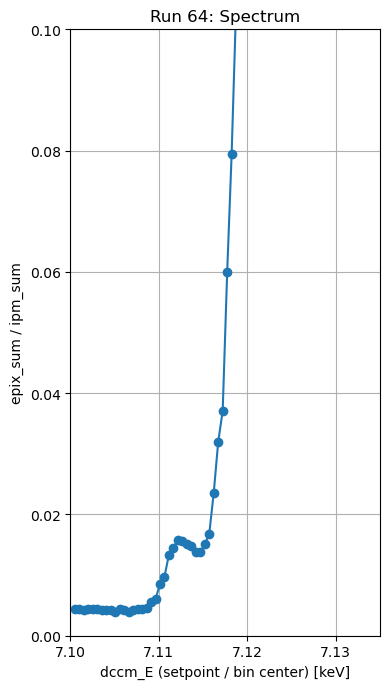

In [12]:
plt.figure(figsize=(4, 7))
plt.plot(x, y, marker='o')
plt.xlabel('dccm_E (setpoint / bin center) [keV]')
plt.ylabel('epix_sum / ipm_sum')
plt.title(f'Run {run}: Spectrum')
plt.grid(True)
plt.xlim(7.100,7.135)
plt.ylim(0.00,0.1)
plt.tight_layout()